In [1]:
import os
from os import path
print(os.getcwd())

import sys
print(sys.version)

import cv2

from RABiTPy import Capture, Identify, Stats, Tracker
from RABiTPy.constants import AvailableOperations, AvailableProps, PropsThreshold 
%matplotlib inline

C:\Users\mcwil\anaconda_projects\82b193c3-02b5-45a5-b486-9a18ed0be078
3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]


In [2]:
'''
capturing data
'''

capture = Capture("./full code")
capture.load_video("sample.avi")

frames = capture.process_video_into_frames(pixel_scale_factor=0.166666, scale_units='um', is_store_video_frames=True, store_images_path='frames')
1080
Video Frame Height: 810

---------- Video Stats ----------
Video Frame Width: 1080
Video Frame Height: 810
Frame Rate: 15.0 FPS
Total Frames: 600.0 frames
Video Duration (s): 40.0
---------------------------------
Video file loaded successfully: ./full code\sample.avi


Frame capture progress: 100%|██████████| 600/600 [00:41<00:00, 14.48it/s]

600 frame(s) captured successfully for the video FPS: 15.0 to the folder: ./full code\frames
Processed video into frames successfully with pixel scale factor: 0.166666 um


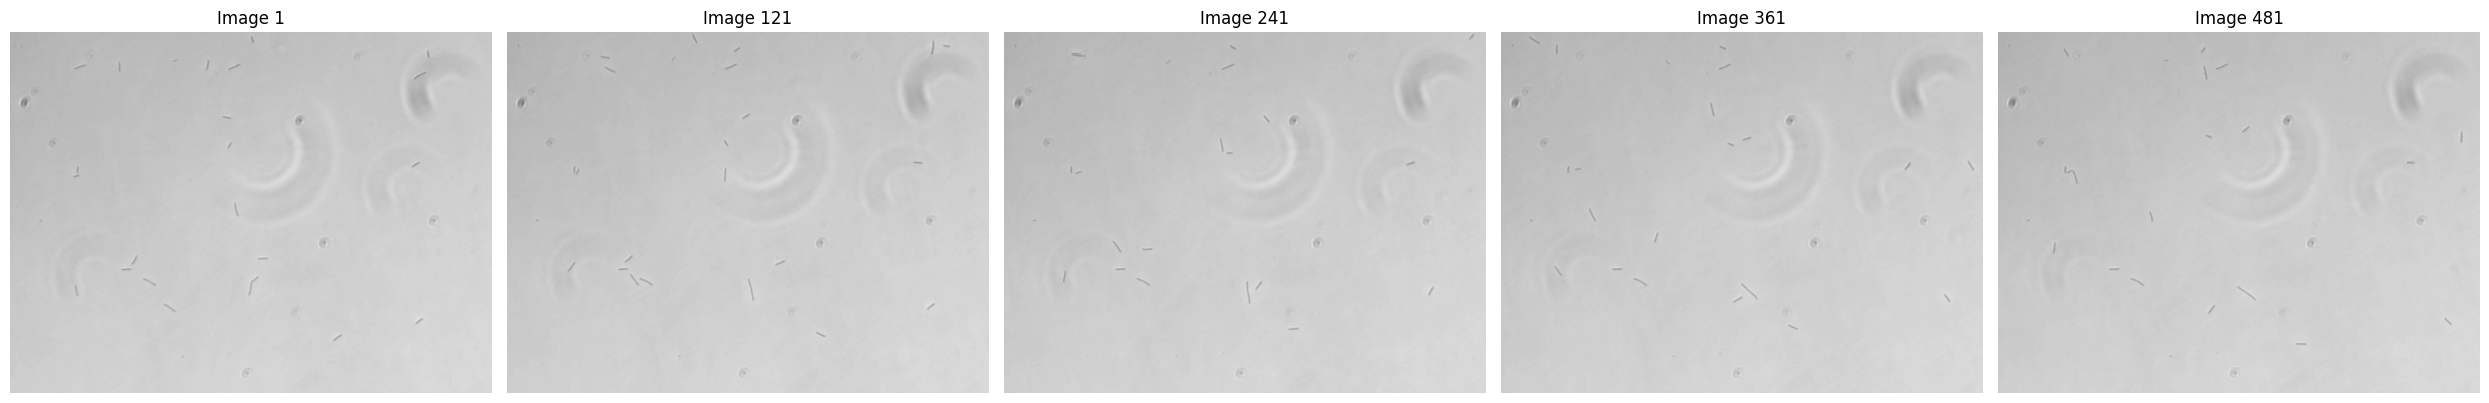

Applying Gaussian adaptive thresholding: 100%|██████████| 600/600 [00:18<00:00, 32.73it/s]


Gaussian adaptive thresholding applied successfully.
NOTE: If dark objects are displayed over a light background, set 'is_color_inverse' to True and redo the thresholding to correct it before proceeding to the next step.


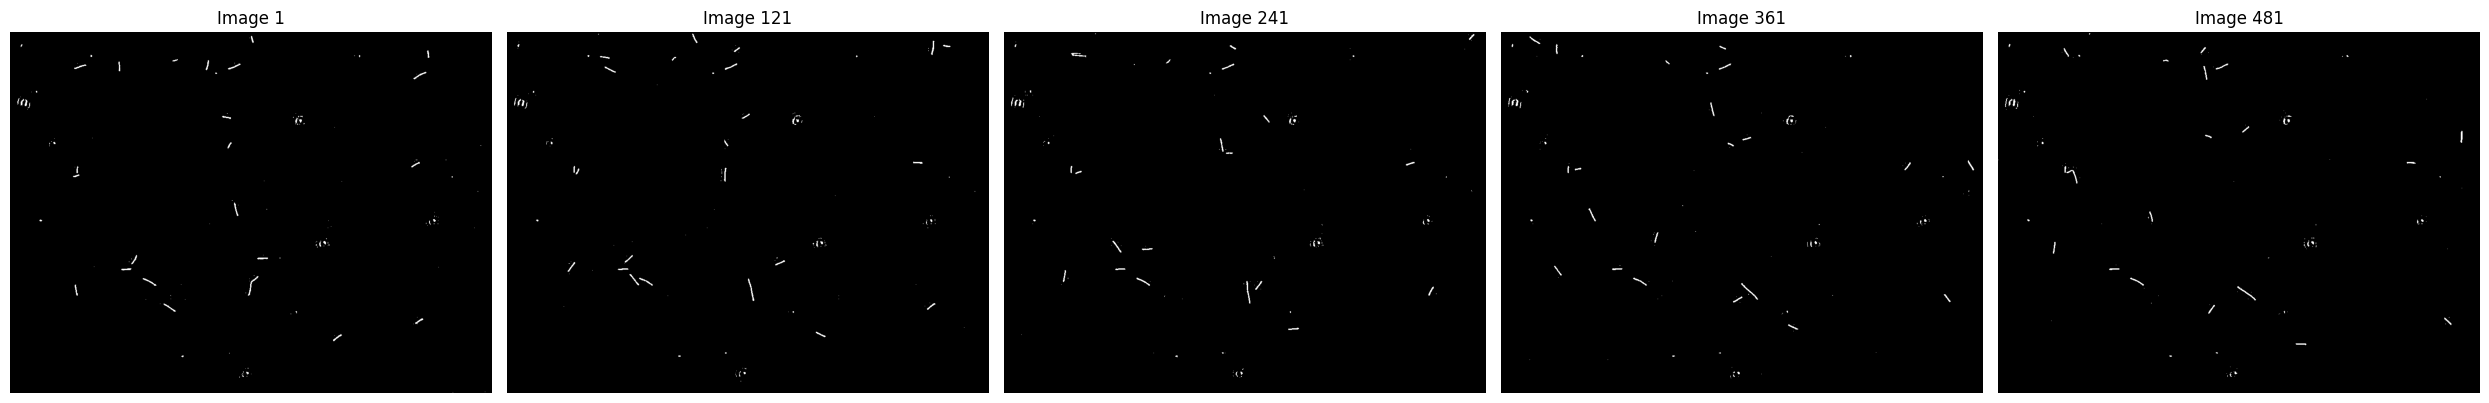

Generating region properties: 100%|██████████| 600/600 [00:32<00:00, 18.53it/s]

Region properties generated successfully.


,label,area,centroid_x,centroid_y,major_axis_length,minor_axis_length,frame
0,1,51.0,18.431373,542.333333,17.417092,3.753117,1
1,2,1.0,15.000000,536.000000,0.000000,0.000000,1
2,3,15.0,32.066667,25.266667,6.721561,2.830500,1
3,4,55.0,51.309091,936.672727,19.003606,3.906023,1
4,5,15.0,55.333333,181.666667,4.818322,3.986839,1
...,...,...,...,...,...,...,...
75416,115,1.0,764.000000,513.000000,0.000000,0.000000,600
75417,116,1.0,767.000000,540.000000,0.000000,0.000000,600
75418,117,5.0,771.200000,512.400000,3.098387,1.788854,600
75419,118,2.0,776.000000,515.500000,2.000000,0.000000,600


In [3]:
'''
thresholding
'''
identify = Identify(capture_frame_object=capture)

#display original frames
identify.show_frames(images_to_show_count=5, images_per_row=5, use_gray_cmap=True)

identify.apply_gaussian_adaptive_thresholding(block_size = 11, c = 5, is_color_inverse = True, is_update_frames = True);
identify.show_frames(images_to_show_count=5, images_per_row=5, use_gray_cmap=True)

view_props = [
    AvailableProps.LABEL, # Label is mandatory for the region properties
    AvailableProps.AREA,
    AvailableProps.CENTROID,
    AvailableProps.MAJOR_AXIS_LENGTH,
    AvailableProps.MINOR_AXIS_LENGTH
]

# Generate region properties for the frames and store them in a DataFrame
region_props_df = identify.generate_region_props_to_dataframe(view_props)

# Display the DataFrame
region_props_df

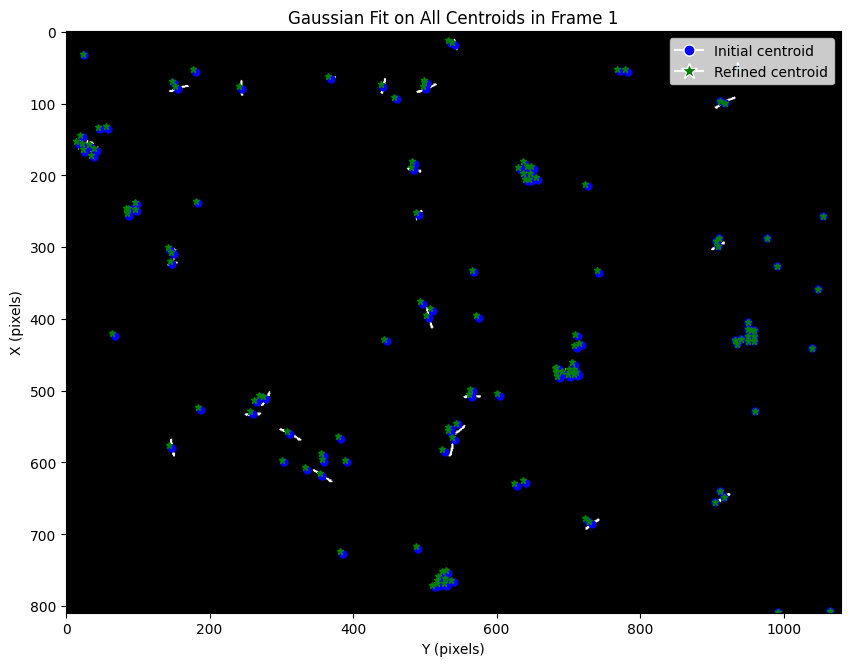

Updating centroids: 100%|██████████| 600/600 [01:37<00:00,  6.16it/s]

Centroids optimized successfully using Gaussian fit.
Filters applied successfully.


In [9]:
identify.visualize_gaussian_fit_on_a_frame(frame_index=1, fit_window=7)
identify.optimize_centroids_using_gaussian_fit(fit_window=7)

from typing import List

# Apply filters on region properties
props_threshold: List[PropsThreshold] = [
    {
        'property': AvailableProps.AREA,               # Property to filter on
        'operation': AvailableOperations.GREATER_THAN, # Operation to perform
        'value': 20                                    # Value to compare with
    }
]

# Apply filters on the generated region properties
filtered_df = identify.apply_filters_on_region_props(props_threshold, is_update_dataframes = True)

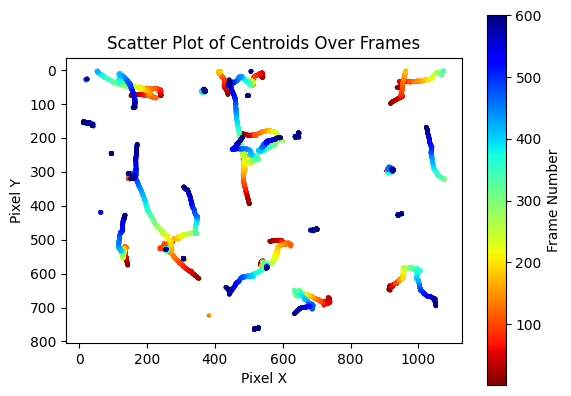

Identified objects saved successfully to path:  ./full code\identified_objects.csv


In [10]:
identify.plot_centroids(show_time=True)

# Save identified objects to CSV
identify.save_identified_objects_to_csv(output_file_name='identified_objects')

Frame 600: 32 trajectories present.
Successfully linked 54 particles.
After filtering based on min 500 frames: 28 unique particles
After filtering based on min 10 displacement filtering: 15 unique particles
Linked dataframes saved to ./full code\linked_particles.csv


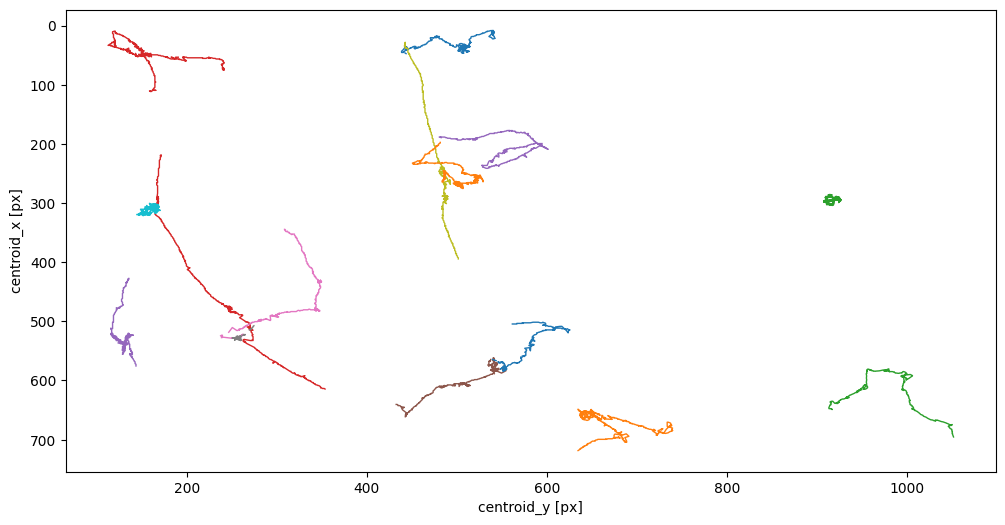

Trajectories plotted successfully.


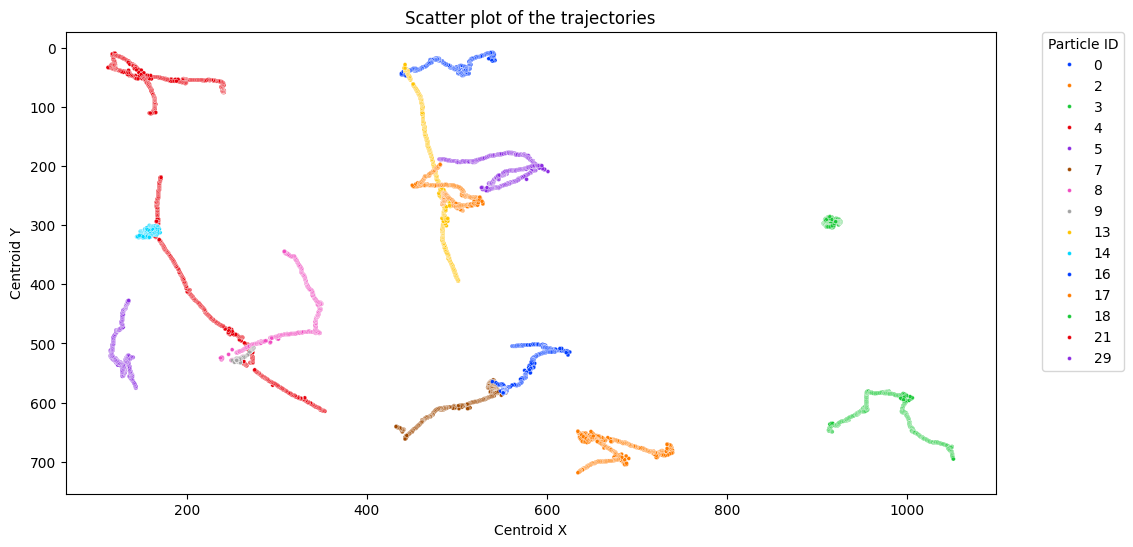

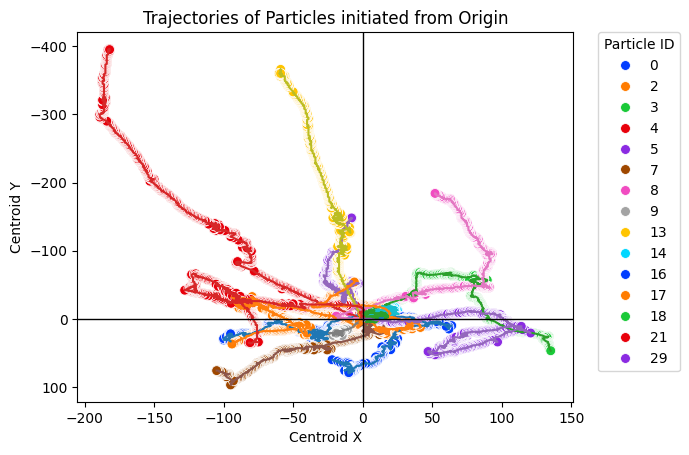

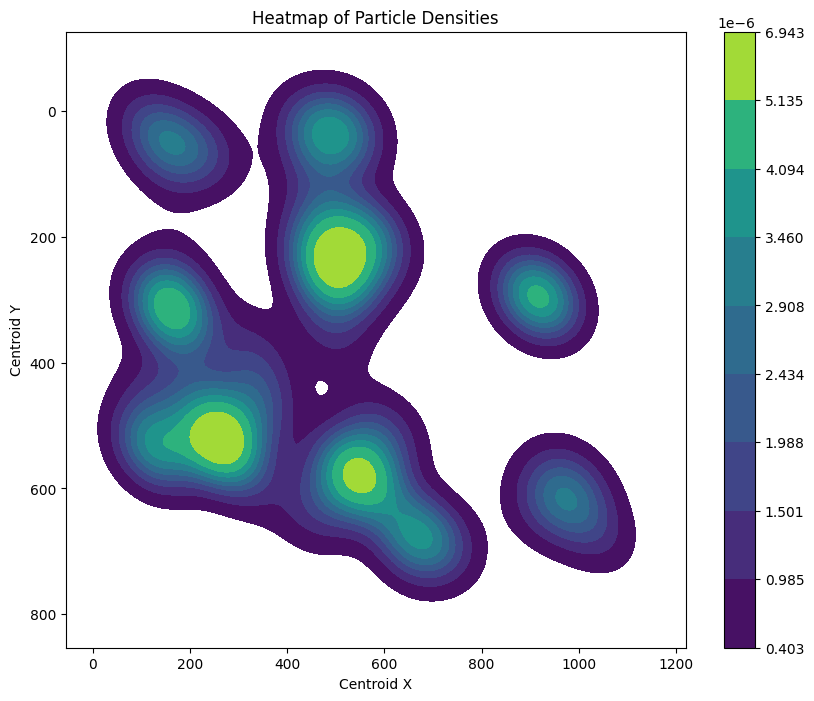

Overlaying Tracks on Video: 100%|██████████| 600/600 [00:12<00:00, 48.01it/s]

Processed video with overlaid tracks saved to ./full code\tracks_overlaid.avi


In [11]:
tracker = Tracker(identify_object=identify)

tracker.link_particles(max_distance=50, max_memory=50, position_columns=['centroid_x', 'centroid_y'])

# Filter particles to retain only those with a minimum number of frames and displacement
tracker.filter_particles(min_frames=500, min_displacement=10, is_update_particles=True)
tracker.save_linked_dataframes(output_file_name='linked_particles')

tracker.plot_trajectories_using_trackpy()
tracker.sort_and_plot_scatter_of_trajectories()
tracker.visualize_particle_trajectories_from_origin()
tracker.visualize_particle_heatmap()

tracker.overlay_tracks_on_video(
    output_video_filename="tracks_overlaid.avi",
    colormap_name="viridis",
    show_labels=True,
    font_scale=1.2
)

Total unique particles: 15


Calculating Speed:   0%|          | 0/15 [00:00<?, ?it/s]

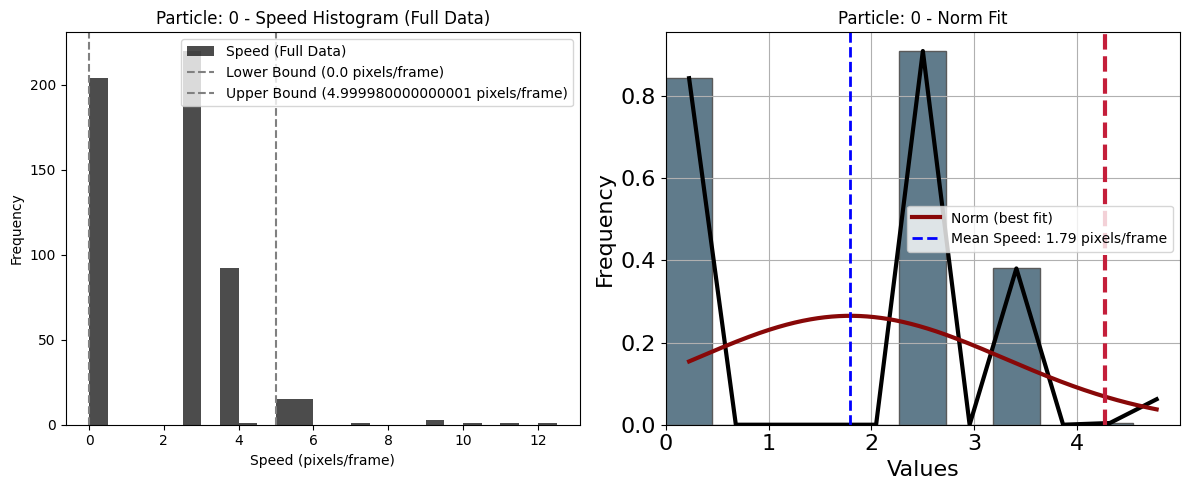

Calculating Speed:   7%|▋         | 1/15 [00:00<00:06,  2.27it/s]

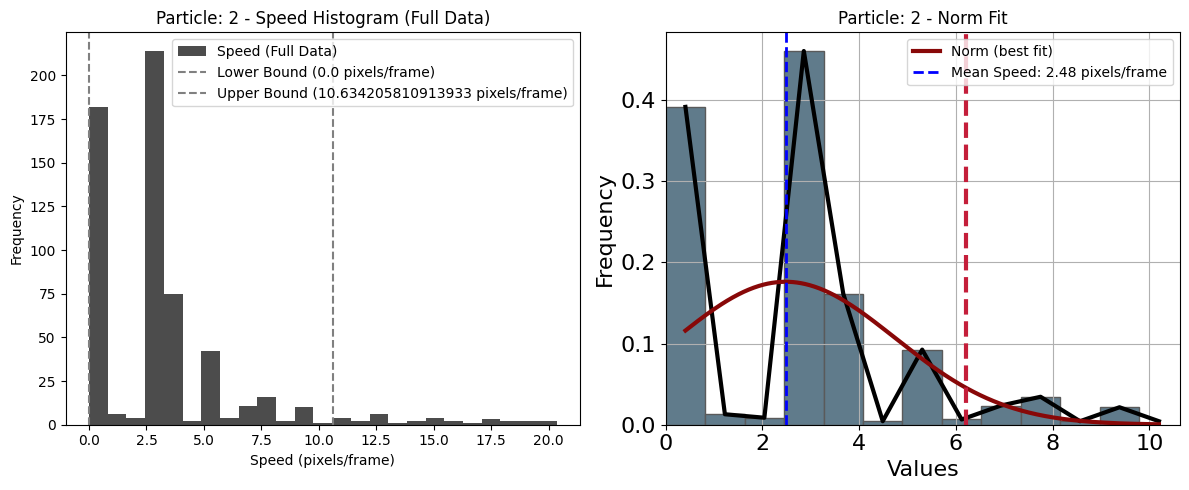

Calculating Speed:  13%|█▎        | 2/15 [00:00<00:05,  2.29it/s]

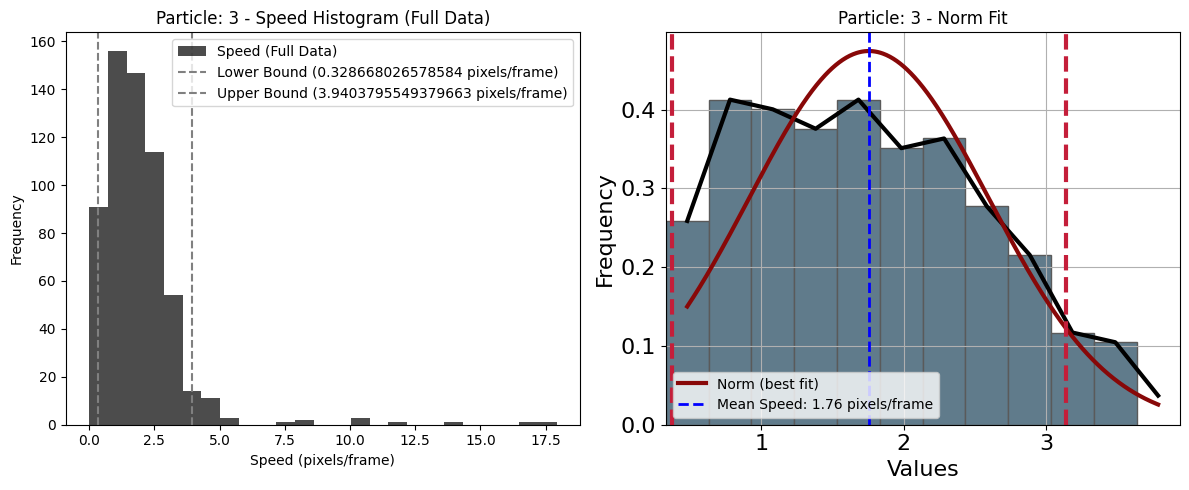

Calculating Speed:  20%|██        | 3/15 [00:01<00:06,  1.97it/s]

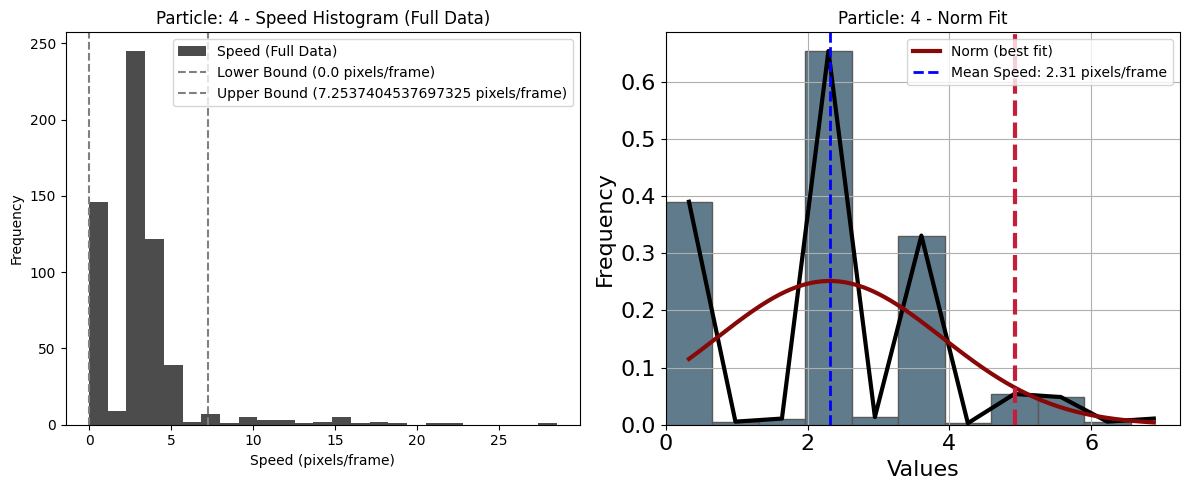

Calculating Speed:  27%|██▋       | 4/15 [00:01<00:05,  2.06it/s]

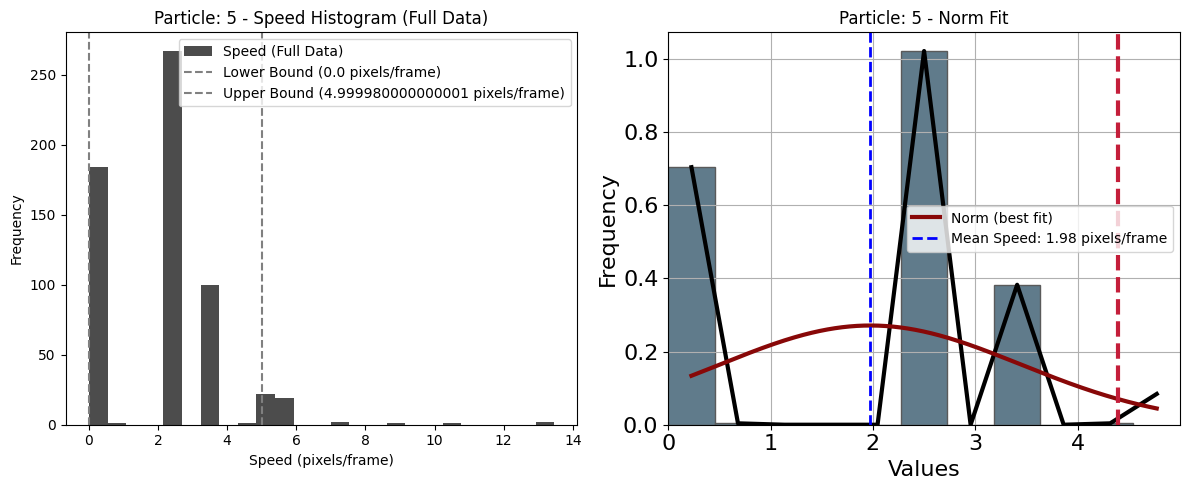

Calculating Speed:  33%|███▎      | 5/15 [00:02<00:05,  1.97it/s]

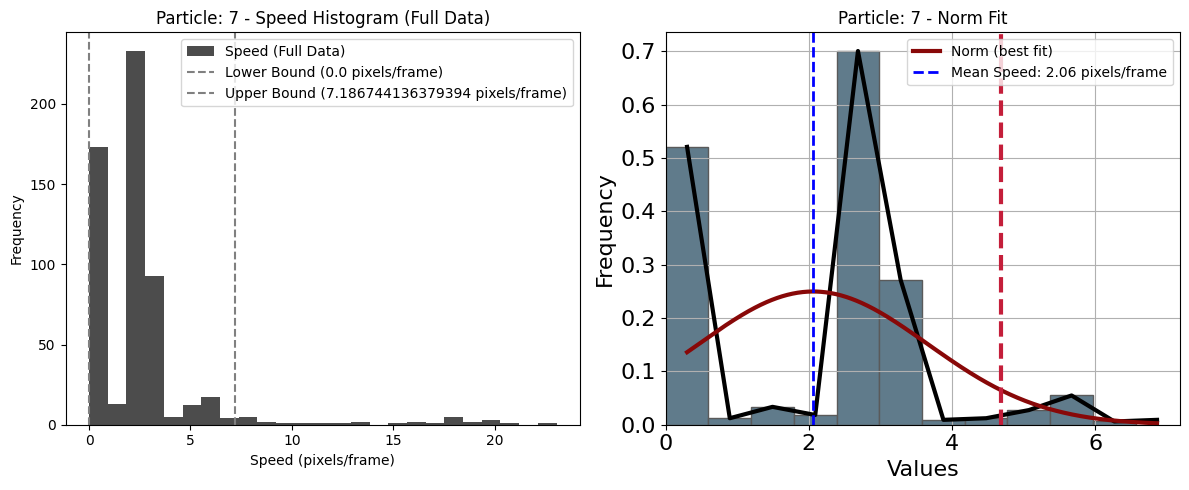

Calculating Speed:  40%|████      | 6/15 [00:02<00:04,  2.12it/s]

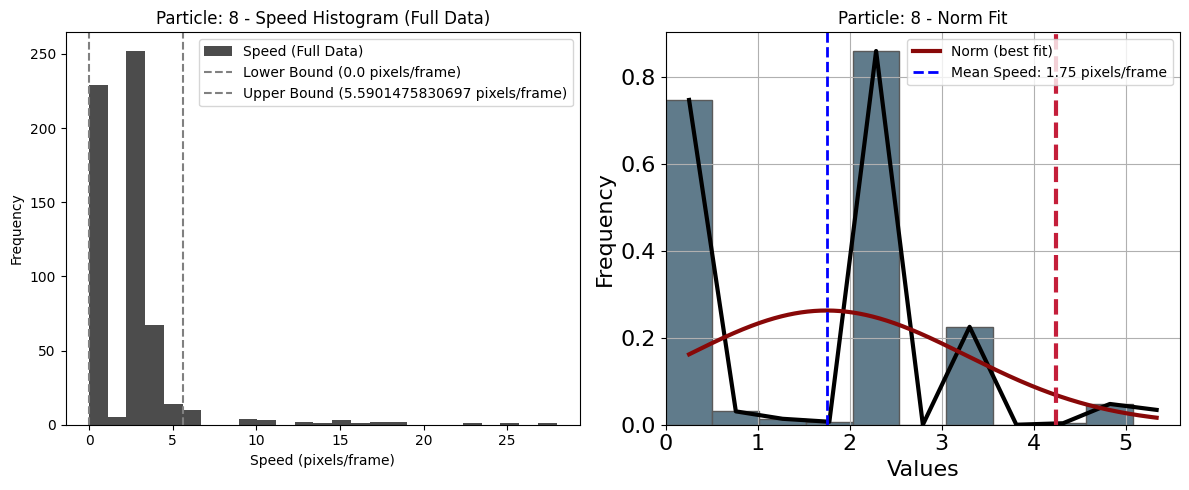

Calculating Speed:  47%|████▋     | 7/15 [00:03<00:03,  2.24it/s]

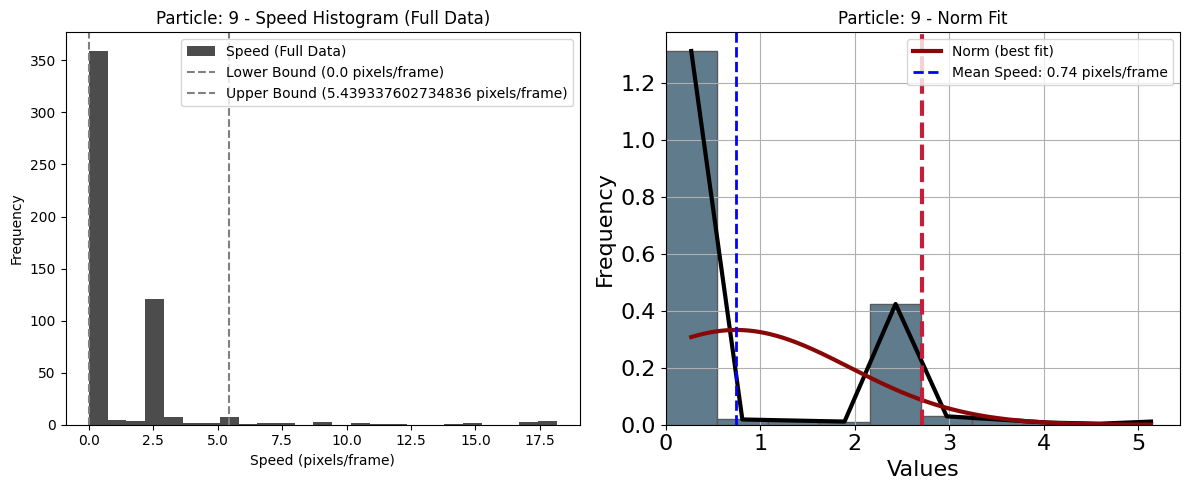

Calculating Speed:  53%|█████▎    | 8/15 [00:03<00:03,  2.20it/s]

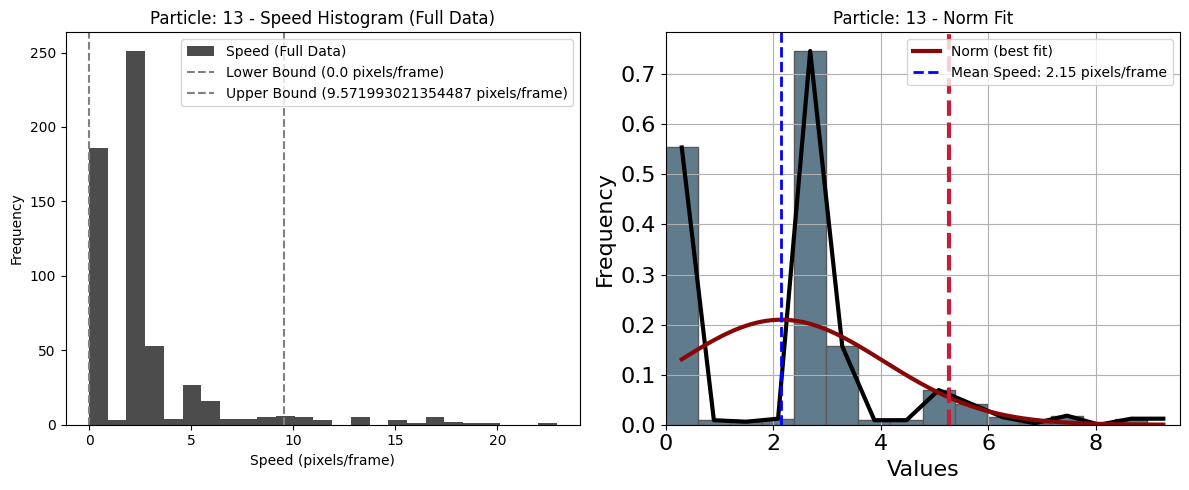

Calculating Speed:  60%|██████    | 9/15 [00:04<00:03,  1.66it/s]

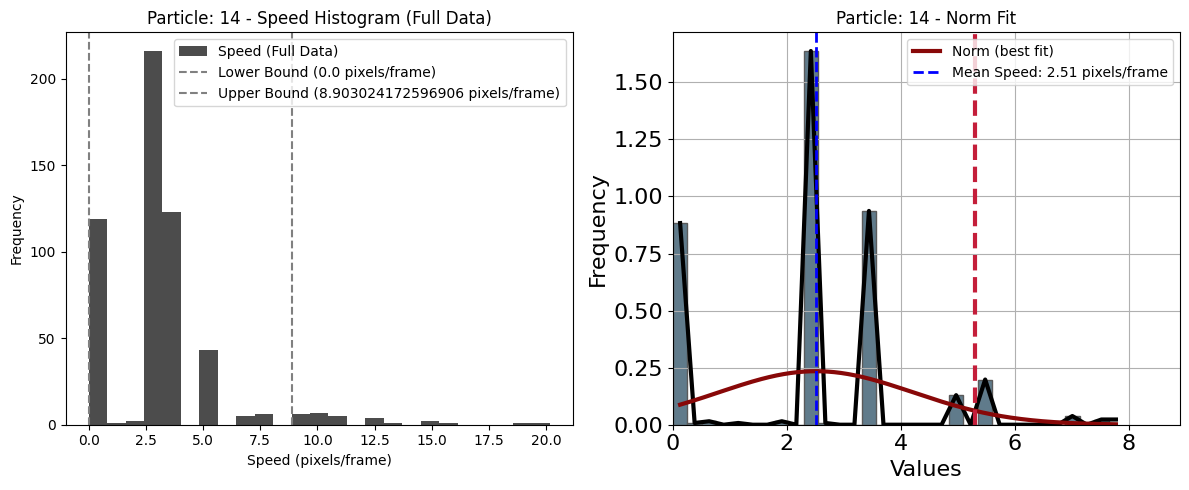

Calculating Speed:  67%|██████▋   | 10/15 [00:05<00:02,  1.75it/s]

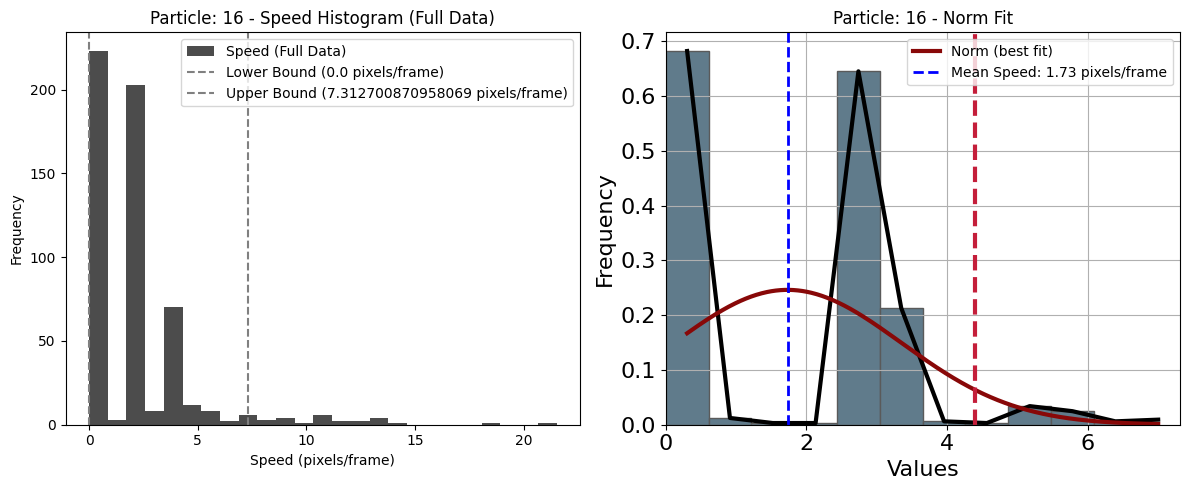

Calculating Speed:  73%|███████▎  | 11/15 [00:05<00:02,  1.80it/s]

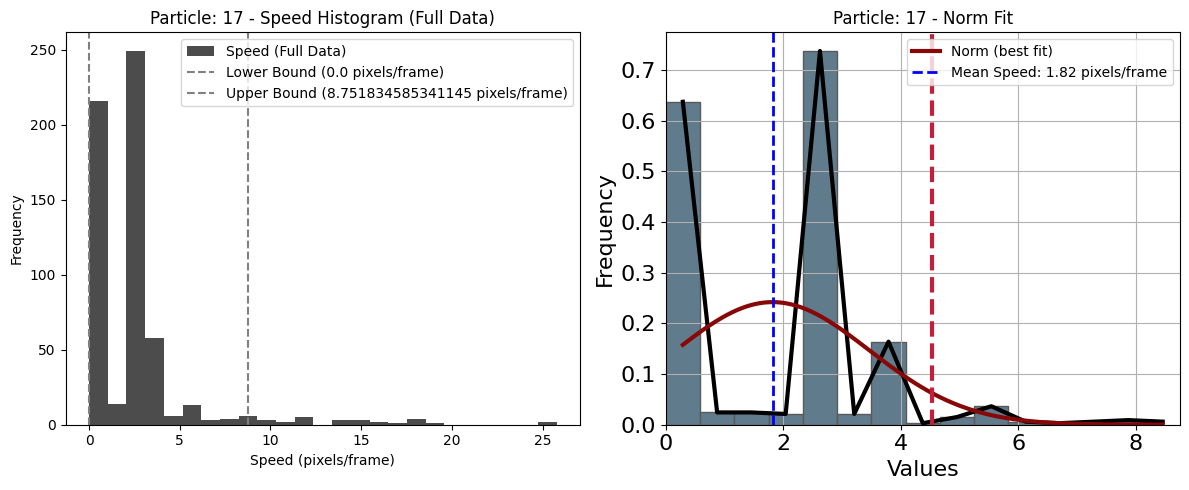

Calculating Speed:  80%|████████  | 12/15 [00:06<00:01,  1.66it/s]

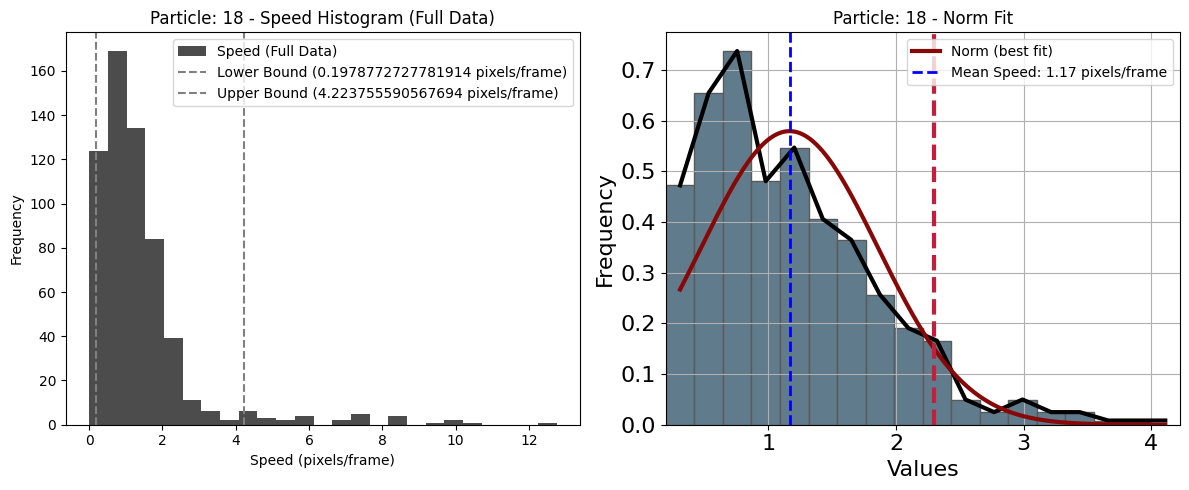

Calculating Speed:  87%|████████▋ | 13/15 [00:06<00:01,  1.68it/s]

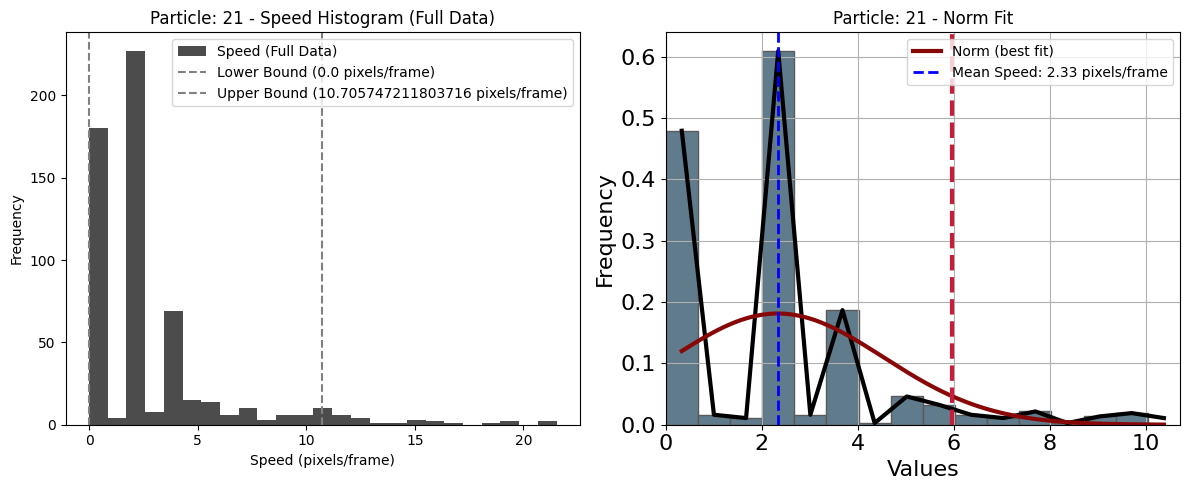

Calculating Speed:  93%|█████████▎| 14/15 [00:07<00:00,  1.74it/s]

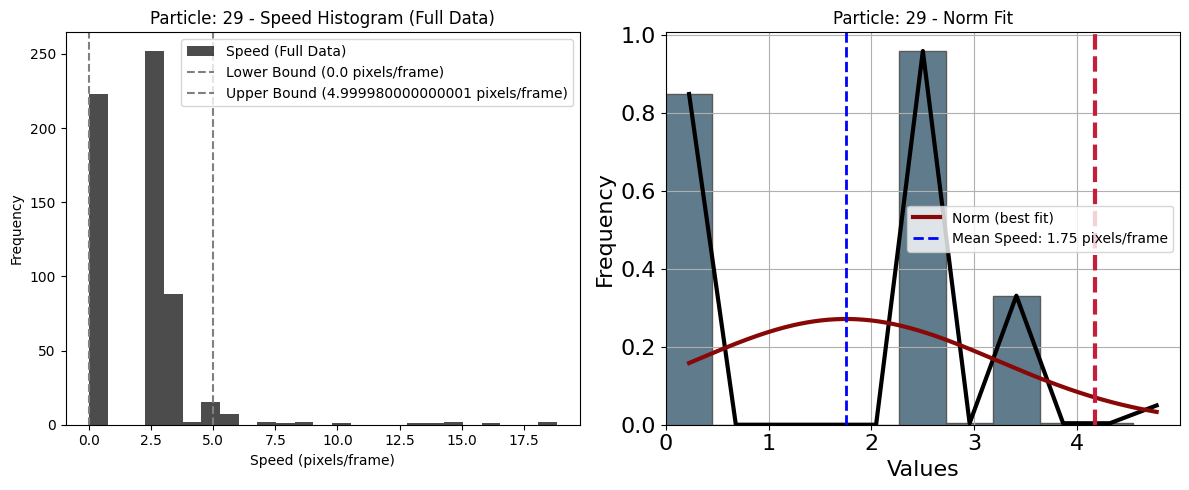

Calculating Speed: 100%|██████████| 15/15 [00:07<00:00,  1.89it/s]


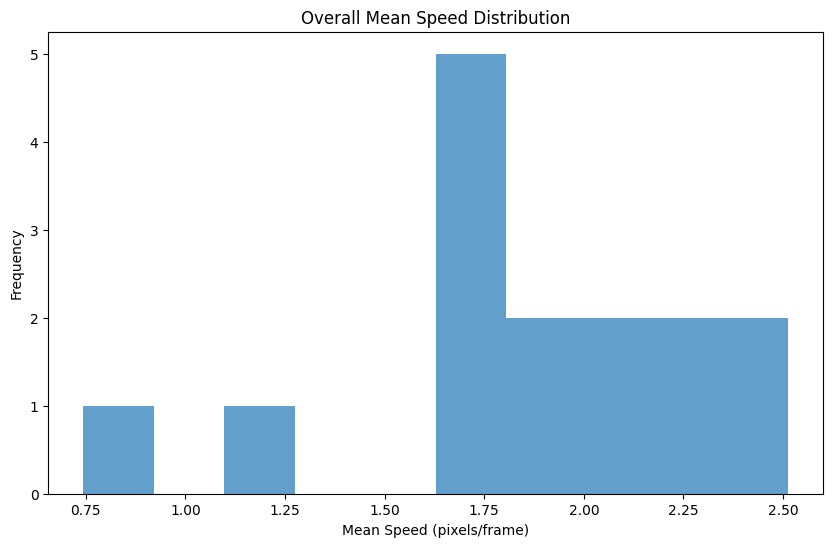

Mean speeds saved to ./full code\mean_speeds.csv


In [12]:
stats = Stats(tracker_object=tracker)

# Calculate the speed and plot the mean of the distribution
stats.calculate_speed_and_plot_mean(distribution_type='norm', ci_range=(5, 95), bin_size=25, speed_unit='pixels/frame')

stats.plot_overall_mean_speed_distribution(bins=10, speed_unit='(pixels/frame)')

# Save the mean speeds to a CSV file
stats.save_mean_speeds(filename='mean_speeds')